Optimizing... Please wait.

Recovered Parameters
Theta (degrees): 29.999993
Theta (radians): 0.5235986496
M               : 0.0300000818
X               : 55.0001008561
Mean Error      : 0.0079552665


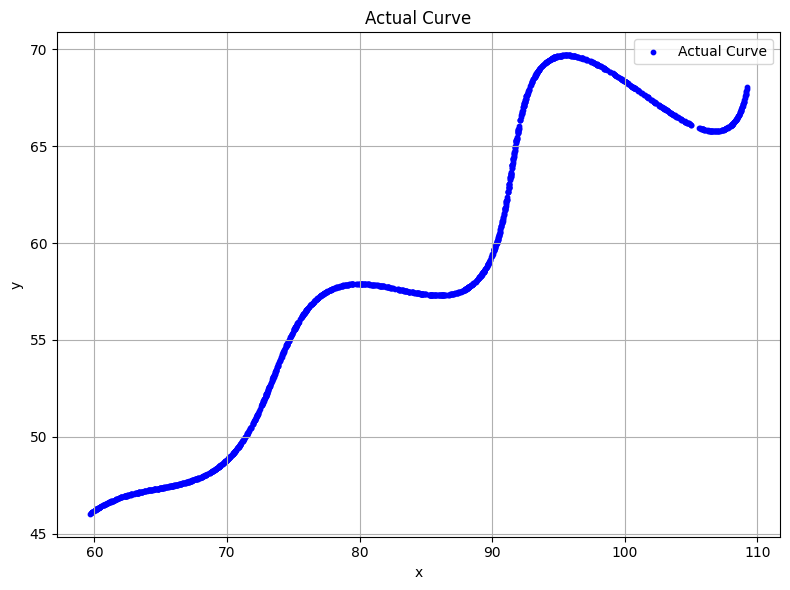

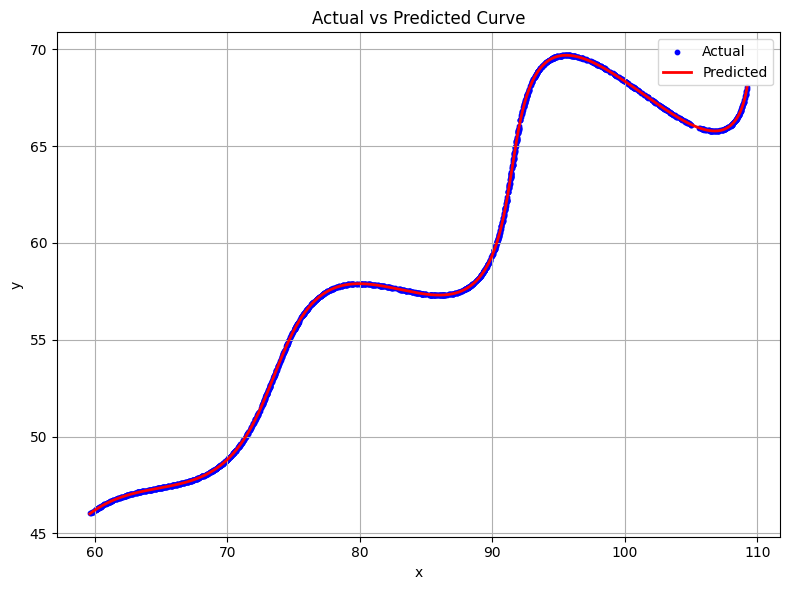

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution
from scipy.spatial import cKDTree

# Load CSV
data = pd.read_csv("xy_data.csv")

data.columns = ["x", "y"]

x_actual = data["x"].values
y_actual = data["y"].values

actual_points = np.column_stack((x_actual, y_actual))

# Parametric Curve
def curve(theta, M, X, num_points=2000):
    t = np.linspace(6, 60, num_points)

    x = (
        t * np.cos(theta)
        - np.exp(M * np.abs(t)) * np.sin(0.3 * t) * np.sin(theta)
        + X
    )

    y = (
        42
        + t * np.sin(theta)
        + np.exp(M * np.abs(t)) * np.sin(0.3 * t) * np.cos(theta)
    )

    return np.column_stack((x, y))


# Objective Function

def objective(params):
    theta, M, X = params

    predicted = curve(theta, M, X)

    tree = cKDTree(predicted)

    dist, _ = tree.query(actual_points)

    return np.mean(dist)


# Bounds

bounds = [
    (np.deg2rad(0.1), np.deg2rad(50)),   # theta
    (-0.05, 0.05),                       # M
    (0, 100)                             # X
]

# Optimization

print("Optimizing... Please wait.\n")

result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    popsize=20,
    maxiter=100,
    tol=1e-8,
    polish=True,
    seed=42
)

theta, M, X = result.x

print("=" * 60)
print("Recovered Parameters")
print("=" * 60)

print(f"Theta (degrees): {np.degrees(theta):.6f}")
print(f"Theta (radians): {theta:.10f}")
print(f"M               : {M:.10f}")
print(f"X               : {X:.10f}")
print(f"Mean Error      : {result.fun:.10f}")

print("=" * 60)

# Generate Predicted Curve

predicted = curve(theta, M, X)

# FIGURE 1 : ACTUAL CURVE ONLY

plt.figure(figsize=(8,6))

plt.scatter(
    x_actual,
    y_actual,
    s=10,
    color="blue",
    label="Actual Curve"
)

plt.title("Actual Curve")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("actual_curve.png", dpi=300)
plt.show()

# FIGURE 2 : ACTUAL vs PREDICTED

plt.figure(figsize=(8,6))

plt.scatter(
    x_actual,
    y_actual,
    s=10,
    color="blue",
    label="Actual"
)

plt.plot(
    predicted[:,0],
    predicted[:,1],
    color="red",
    linewidth=2,
    label="Predicted"
)

plt.title("Actual vs Predicted Curve")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=300)
plt.show()